# FX Pairs: Feature Engineering

**Chapter 8: Feature Engineering**

This notebook implements feature engineering for the FX Pairs case study
at **daily** frequency (NY 5PM close), aligned with the setup and label
design from Chapters 6 and 7.

**Learning Objectives**:
- Compute mean-reversion features (z-scores and distance from rolling extremes)
- Build multi-horizon momentum and risk-adjusted momentum features
- Construct cross-sectional rank features across 20 currency pairs
- Add USD factor decomposition to separate systematic from idiosyncratic moves
- Engineer volatility regime features (Garman-Klass, vol ratios)

**Book Reference**: Chapter 8, Sections 8.2-8.4

**Prerequisites**: FX daily price data (via `load_fx_pairs()` canonical loader)

**Output Contract**:
- Time key: `timestamp` (daily NY 5PM close)
- Asset key: `symbol`
- Output: `features/financial.parquet` (~50 features)

In [1]:
"""FX Pairs: Feature Engineering."""

import subprocess
import warnings
from datetime import UTC, date, datetime
from itertools import combinations

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from ml4t.diagnostic.splitters.calendar import TradingCalendar
from scipy.stats import spearmanr as _spearmanr

from data import load_fx_pairs
from utils.cv_splits import load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "fx_pairs"
START_DATE = "2011-01-01"
MAX_SYMBOLS = 0

In [3]:
CASE_DIR = get_case_study_dir("fx_pairs")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

## 1. Load Daily Prices

We aggregate 4-hour bars to daily using the NY 5PM rollover convention,
matching the labels pipeline exactly. Weekend dates are excluded.

In [4]:
fx_4h = load_fx_pairs(
    frequency="4h",
    start_date=START_DATE,
).select(["symbol", "timestamp", "open", "high", "low", "close", "volume"])

# Assign trading sessions via CME_FX calendar, then aggregate to daily.
# Retain the original 4H timestamp as `bar_ts` so OHLC sort_by inside agg
# is order-safe (polars group_by does not contractually preserve row order).
cal = TradingCalendar("CME_FX")
sessions = cal.get_sessions(pd.DatetimeIndex(fx_4h["timestamp"].to_pandas()))
fx_4h = (
    fx_4h.rename({"timestamp": "bar_ts"})
    .with_columns(pl.Series("timestamp", sessions.values).cast(pl.Date))
    .drop_nulls("timestamp")
)

prices = (
    fx_4h.group_by(["symbol", "timestamp"])
    .agg(
        pl.col("open").sort_by("bar_ts").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").sort_by("bar_ts").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort(["symbol", "timestamp"])
)
print(f"Loaded daily prices: {len(prices):,} rows")

n_assets = prices["symbol"].n_unique()
n_dates = prices["timestamp"].n_unique()
ASSETS = sorted(prices["symbol"].unique().to_list())
print(f"Universe: {n_assets} pairs, {n_dates} dates")
print(f"Period: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

Loaded daily prices: 77,480 rows
Universe: 20 pairs, 3874 dates
Period: 2011-01-03 to 2025-12-31


## 2. Base Returns

Compute returns at multiple horizons. These serve as building blocks for
all downstream features.

In [5]:
MOMENTUM_DAYS = {
    "1d": 1,
    "5d": 5,
    "10d": 10,
    "21d": 21,
    "42d": 42,
    "63d": 63,
    "126d": 126,
    "252d": 252,
}

df = prices.sort(["symbol", "timestamp"])

# Daily returns (clip(1e-8) guards against div-by-zero → inf)
df = df.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol").clip(lower_bound=1e-8) - 1).alias(
        "ret_1d"
    )
)

# Multi-horizon returns
for name, period in MOMENTUM_DAYS.items():
    if name == "1d":
        continue  # Already computed
    df = df.with_columns(
        (
            pl.col("close") / pl.col("close").shift(period).over("symbol").clip(lower_bound=1e-8)
            - 1
        ).alias(f"ret_{name}")
    )

print(f"Computed returns at {len(MOMENTUM_DAYS)} horizons")

Computed returns at 8 horizons


## 3. Mean-Reversion Features

Mean-reversion is the primary hypothesis for this case study. We compute
z-scores of returns and distance from rolling highs/lows.

**Note on `min_periods`**: Polars `rolling_mean`/`rolling_std` default to
`min_periods=window_size`, so early rows with incomplete windows are
automatically null (safe warmup behavior). No explicit `min_periods` needed.

In [6]:
# Z-score of returns: (current return - rolling mean) / rolling std
for ret_horizon, z_window in [("21d", 252), ("63d", 252), ("126d", 252)]:
    df = df.with_columns(
        (
            (
                pl.col(f"ret_{ret_horizon}")
                - pl.col(f"ret_{ret_horizon}").rolling_mean(z_window).over("symbol")
            )
            / (pl.col(f"ret_{ret_horizon}").rolling_std(z_window).over("symbol") + 1e-10)
        ).alias(f"zscore_{ret_horizon}")
    )

# Distance from rolling highs/lows (normalized channel position)
for name, period in [("21d", 21), ("63d", 63), ("126d", 126)]:
    df = df.with_columns(
        pl.col("close").rolling_max(period).over("symbol").alias(f"_high_{name}"),
        pl.col("close").rolling_min(period).over("symbol").alias(f"_low_{name}"),
    )
    df = df.with_columns(
        (
            (pl.col("close") - pl.col(f"_low_{name}"))
            / (pl.col(f"_high_{name}") - pl.col(f"_low_{name}") + 1e-10)
        ).alias(f"channel_pos_{name}")
    )
    df = df.drop([f"_high_{name}", f"_low_{name}"])

# Skip-recent momentum: return from 12 months ago through one month ago
df = df.with_columns(
    (
        pl.col("close").shift(21).over("symbol")
        / pl.col("close").shift(252).over("symbol").clip(lower_bound=1e-8)
        - 1
    ).alias("mom_skip_recent")
)

print("Mean-reversion features: 3 z-scores, 3 channel positions, 1 skip-recent")

Mean-reversion features: 3 z-scores, 3 channel positions, 1 skip-recent


## 4. Volatility Features

Garman-Klass volatility is more efficient than close-to-close because it uses
OHLC data. Vol ratios serve as regime indicators.

Maximum drawdown is the worst peak-to-trough decline anywhere within the
trailing window, rather than only the current distance below a prior high.

In [7]:
def maximum_drawdown(window: pl.Series) -> float:
    """Return the worst peak-to-trough decline in a price window."""
    values = window.to_numpy()
    running_peak = np.maximum.accumulate(values)
    return float(np.min(values / running_peak - 1))

In [8]:
# Garman-Klass volatility (uses OHLC, more efficient than close-to-close)
df = df.with_columns(
    (
        0.5 * (pl.col("high") / pl.col("low")).log().pow(2)
        - (2 * np.log(2) - 1) * (pl.col("close") / pl.col("open")).log().pow(2)
    ).alias("_gk_daily")
)

ANNUALIZATION = np.sqrt(252)
for name, period in [("21d", 21), ("63d", 63), ("126d", 126), ("252d", 252)]:
    df = df.with_columns(
        (pl.col("_gk_daily").rolling_mean(period).over("symbol").sqrt() * ANNUALIZATION).alias(
            f"vol_gk_{name}"
        )
    )

# Close-to-close volatility for comparison
for name, period in [("21d", 21), ("63d", 63)]:
    df = df.with_columns(
        (pl.col("ret_1d").rolling_std(period).over("symbol") * ANNUALIZATION).alias(
            f"vol_cc_{name}"
        )
    )

# Vol ratios (regime indicator: short/long vol)
df = df.with_columns(
    (pl.col("vol_gk_21d") / (pl.col("vol_gk_63d") + 1e-10)).alias("vol_ratio_21_63"),
    (pl.col("vol_gk_63d") / (pl.col("vol_gk_252d") + 1e-10)).alias("vol_ratio_63_252"),
)

# Max drawdown over 63 days
df = df.with_columns(
    pl.col("close")
    .rolling_map(maximum_drawdown, window_size=63, min_samples=63)
    .over("symbol")
    .alias("max_dd_63d")
)

df = df.drop("_gk_daily")
print("Volatility features: 4 GK vol, 2 CC vol, 2 vol ratios, 1 max drawdown")

Volatility features: 4 GK vol, 2 CC vol, 2 vol ratios, 1 max drawdown


## 5. Risk-Adjusted Momentum (Sharpe-like Ratios)

In [9]:
for ret_h, vol_h in [("21d", "21d"), ("63d", "63d"), ("126d", "126d")]:
    df = df.with_columns(
        (pl.col(f"ret_{ret_h}") / (pl.col(f"vol_gk_{vol_h}") + 1e-4)).alias(f"sharpe_{ret_h}")
    )

# Momentum acceleration (change in momentum over time)
df = df.with_columns(
    (pl.col("ret_21d") - pl.col("ret_63d")).alias("accel_21_63"),
    (pl.col("ret_63d") - pl.col("ret_126d")).alias("accel_63_126"),
)

print("Risk-adjusted momentum: 3 Sharpe ratios, 2 acceleration")

Risk-adjusted momentum: 3 Sharpe ratios, 2 acceleration


## 6. Cross-Sectional Rank Features

Percentile ranks across the 20-pair universe at each date. These capture
relative positioning, which is critical for a long-short rank strategy.

In [10]:
# Momentum ranks
for name in ["21d", "63d", "126d"]:
    df = df.with_columns(
        (
            pl.col(f"ret_{name}").rank().over("timestamp")
            / pl.col(f"ret_{name}").count().over("timestamp")
        ).alias(f"rank_ret_{name}")
    )

# Volatility ranks
for name in ["21d", "63d"]:
    df = df.with_columns(
        (
            pl.col(f"vol_gk_{name}").rank().over("timestamp")
            / pl.col(f"vol_gk_{name}").count().over("timestamp")
        ).alias(f"rank_vol_{name}")
    )

# Sharpe ranks
for name in ["21d", "63d", "126d"]:
    df = df.with_columns(
        (
            pl.col(f"sharpe_{name}").rank().over("timestamp")
            / pl.col(f"sharpe_{name}").count().over("timestamp")
        ).alias(f"rank_sharpe_{name}")
    )

print("Cross-sectional ranks: 3 return, 2 volatility, 3 Sharpe")

Cross-sectional ranks: 3 return, 2 volatility, 3 Sharpe


## 7. USD Factor Decomposition

Seven of the 20 pairs contain USD. A transparent signed average of their
daily returns provides a USD-strength proxy that can distinguish broad
dollar moves from pair-specific variation. The rolling correlations below
measure exposure to that proxy; they are not a PCA decomposition.

In [11]:
# Identify USD pairs and their sign convention
# For USD/XXX pairs, a positive return = USD strengthening
# For XXX/USD pairs, a positive return = USD weakening
USD_LONG_PAIRS = ["USD_CAD", "USD_CHF", "USD_JPY"]  # USD is base (long USD)
USD_SHORT_PAIRS = [
    "AUD_USD",
    "EUR_USD",
    "GBP_USD",
    "NZD_USD",
]  # USD is quote (short USD)

# Compute USD return factor: average USD-denominated return per date
# For USD/XXX: use return directly (positive = USD strong)
# For XXX/USD: negate return (positive = USD strong)
usd_returns = df.filter(pl.col("symbol").is_in(USD_LONG_PAIRS + USD_SHORT_PAIRS)).with_columns(
    pl.when(pl.col("symbol").is_in(USD_LONG_PAIRS))
    .then(pl.col("ret_1d"))
    .otherwise(-pl.col("ret_1d"))
    .alias("usd_ret")
)

usd_factor = (
    usd_returns.group_by("timestamp")
    .agg(pl.col("usd_ret").mean().alias("usd_factor_1d"))
    .sort("timestamp")
)

# Multi-horizon USD factor (rolling sum of daily)
usd_factor = usd_factor.with_columns(
    pl.col("usd_factor_1d").rolling_sum(21).alias("usd_factor_21d"),
    pl.col("usd_factor_1d").rolling_sum(63).alias("usd_factor_63d"),
)

# Join USD factor to main DataFrame
df = df.join(usd_factor, on="timestamp", how="left")

### Rolling Exposure to the USD Proxy

The backward-looking rolling correlation measures whether each pair has moved
with the broad USD proxy over the past year.

In [12]:
# The legacy `usd_beta_*` fields store rolling correlations rather than
# regression coefficients. The names remain stable for downstream consumers.
# Point-in-time safe: rolling_corr is backward-looking (window_size=252 past days),
# and both inputs (pair return, USD factor) are backward-looking chain.
for horizon in ["21d", "63d"]:
    df = df.with_columns(
        pl.rolling_corr(
            pl.col(f"ret_{horizon}"),
            pl.col(f"usd_factor_{horizon}"),
            window_size=252,
        )
        .over("symbol")
        .alias(f"usd_beta_{horizon}")
    )

print("USD proxy: 3 return aggregates, 2 pair-level rolling correlations")

USD proxy: 3 return aggregates, 2 pair-level rolling correlations


## 8. Technical Indicators

Standard technical indicators at daily frequency. These are supplementary
features -- less theoretically motivated but widely used.

In [13]:
# RSI (Relative Strength Index) at 14d and 63d
for period in [14, 63]:
    df = df.with_columns(
        pl.when(pl.col("ret_1d") > 0)
        .then(pl.col("ret_1d"))
        .otherwise(0.0)
        .rolling_mean(period)
        .over("symbol")
        .alias(f"_avg_gain_{period}"),
        pl.when(pl.col("ret_1d") < 0)
        .then(-pl.col("ret_1d"))
        .otherwise(0.0)
        .rolling_mean(period)
        .over("symbol")
        .alias(f"_avg_loss_{period}"),
    )
    df = df.with_columns(
        (
            100
            - 100 / (1 + pl.col(f"_avg_gain_{period}") / (pl.col(f"_avg_loss_{period}") + 1e-10))
        ).alias(f"rsi_{period}d")
    )
    df = df.drop([f"_avg_gain_{period}", f"_avg_loss_{period}"])

### Price Location and Range Expansion

Bollinger position, moving-average distance, and normalized intraday range
describe where the current close sits relative to recent price behavior.

In [14]:
# Bollinger %B (21-day)
df = df.with_columns(
    pl.col("close").rolling_mean(21).over("symbol").alias("_bb_mid"),
    pl.col("close").rolling_std(21).over("symbol").alias("_bb_std"),
)
df = df.with_columns(
    pl.when(pl.col("_bb_std") > 0)
    .then((pl.col("close") - (pl.col("_bb_mid") - 2 * pl.col("_bb_std"))) / (4 * pl.col("_bb_std")))
    .otherwise(None)
    .alias("bollinger_pctb_21d")
)
df = df.drop(["_bb_mid", "_bb_std"])

# Moving average ratios (price relative to MA)
for period in [21, 63, 252]:
    df = df.with_columns(
        (
            pl.col("close")
            / pl.col("close").rolling_mean(period).over("symbol").clip(lower_bound=1e-8)
            - 1
        ).alias(f"price_to_ma_{period}d")
    )

# Average normalized intraday range measures range expansion
df = df.with_columns(((pl.col("high") - pl.col("low")) / pl.col("close")).alias("_daily_range"))
for period in [21, 63]:
    df = df.with_columns(
        pl.col("_daily_range").rolling_mean(period).over("symbol").alias(f"avg_range_{period}d")
    )
df = df.drop("_daily_range")

print("Technical: 2 RSI, 1 Bollinger, 3 MA ratios, 2 avg range")

Technical: 2 RSI, 1 Bollinger, 3 MA ratios, 2 avg range


## 9. Carry Proxy

True FX carry requires interest rate differentials, which are not in the
OANDA dataset. The legacy `carry_proxy` field is risk-adjusted momentum, not
an interest-rate differential. It remains for downstream compatibility and
should be interpreted only as a trend control.

In [15]:
df = df.with_columns((pl.col("ret_63d") / (pl.col("vol_gk_63d") + 1e-4)).alias("carry_proxy"))
df = df.with_columns(
    (
        pl.col("carry_proxy").rank().over("timestamp")
        / pl.col("carry_proxy").count().over("timestamp")
    ).alias("rank_carry_proxy")
)

print("Carry proxy: 1 risk-adjusted momentum, 1 rank")

Carry proxy: 1 risk-adjusted momentum, 1 rank


## 10. Assemble Feature Matrix

Select features, drop metadata columns, and validate.

In [16]:
# Define all feature columns
FEATURE_COLS = sorted(
    [
        c
        for c in df.columns
        if c
        not in {
            "timestamp",
            "symbol",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "ret_1d",  # Reserved as the shortest-horizon return baseline
        }
        and not c.startswith("_")
    ]
)

# Build output: date + asset + features
output_cols = ["timestamp", "symbol"] + FEATURE_COLS
output_df = df.select(output_cols)

# Drop rows where all features are null (warmup period)
n_before = len(output_df)
output_df = output_df.filter(pl.any_horizontal(pl.col(c).is_not_null() for c in FEATURE_COLS))

### Matrix Integrity Summary

The compact checks below expose coverage, warmup loss, and the worst remaining
null rate before the artifact is written.

In [17]:
# Count features and validate
n_features = len(FEATURE_COLS)
n_rows = len(output_df)
null_pct = output_df.select(pl.col(c).is_null().mean() for c in FEATURE_COLS).row(0)
max_null = max(null_pct)

print(f"\n{'=' * 60}")
print("FEATURE MATRIX SUMMARY")
print(f"{'=' * 60}")
print(f"Shape: {n_rows:,} rows x {n_features} features")
print(f"Pairs: {output_df['symbol'].n_unique()}")
print(f"Dates: {output_df['timestamp'].n_unique()}")
print(f"Period: {output_df['timestamp'].min()} to {output_df['timestamp'].max()}")
print(f"Rows dropped (warmup): {n_before - n_rows:,}")
print(f"Max null %: {max_null:.1%}")


FEATURE MATRIX SUMMARY
Shape: 77,460 rows x 51 features
Pairs: 20
Dates: 3873
Period: 2011-01-04 to 2025-12-31
Rows dropped (warmup): 20
Max null %: 9.7%


### Feature Family Summary

In [18]:
families = {
    "Mean Reversion": [c for c in FEATURE_COLS if "zscore" in c or "channel" in c or "skip" in c],
    "Momentum": [c for c in FEATURE_COLS if c.startswith("ret_") and "rank" not in c],
    "Volatility": [c for c in FEATURE_COLS if "vol_" in c and "rank" not in c],
    "Risk-Adjusted": [c for c in FEATURE_COLS if "sharpe" in c and "rank" not in c]
    + [c for c in FEATURE_COLS if "accel" in c],
    "Cross-Sectional Rank": [c for c in FEATURE_COLS if c.startswith("rank_") and "carry" not in c],
    "USD Factor": [c for c in FEATURE_COLS if "usd_" in c],
    "Technical": [
        c
        for c in FEATURE_COLS
        if any(c.startswith(p) for p in ("rsi_", "bollinger", "price_to_ma", "avg_range"))
    ],
    "Carry Proxy": [c for c in FEATURE_COLS if "carry" in c],
    "Drawdown": [c for c in FEATURE_COLS if "max_dd" in c],
}

print("\nFeature Families:")
assigned = set()
for family, cols in families.items():
    actual = [c for c in cols if c in FEATURE_COLS]
    assigned.update(actual)
    if actual:
        print(f"  {family}: {len(actual)} features")

unassigned = set(FEATURE_COLS) - assigned
if unassigned:
    print(f"  Uncategorized: {len(unassigned)} features -- {sorted(unassigned)}")

print(f"\nTotal: {n_features} features across {len([f for f in families.values() if f])} families")


Feature Families:
  Mean Reversion: 7 features
  Momentum: 7 features
  Volatility: 8 features
  Risk-Adjusted: 5 features
  Cross-Sectional Rank: 8 features
  USD Factor: 5 features
  Technical: 8 features
  Carry Proxy: 2 features
  Drawdown: 1 features

Total: 51 features across 9 families


## 11. Save Feature Matrix

In [19]:
output_path = FEATURES_DIR / "financial.parquet"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
output_df.write_parquet(output_path)
print(f"\nSaved: {output_path.relative_to(CASE_DIR)}")
print(f"  Shape: {output_df.shape}")


Saved: features/financial.parquet
  Shape: (77460, 53)


## 12. Feature Evaluation

We screen each engineered feature against the primary one-day forward return.
The cross-sectional Spearman IC is computed at each date and averaged through
time. Newey-West standard errors account for serial dependence in that daily
IC series, while Benjamini-Hochberg controls the false discovery rate across
all testable engineered features. Three USD factor aggregates are identical
across symbols on a given date, so they have no cross-sectional IC and are
excluded from the multiple-testing family.

This diagnostic can influence later modeling choices, so it uses only the
development window. A signal date is eligible only when its forward-return
endpoint falls strictly before the sealed holdout boundary in `setup.yaml`.

In [20]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family for FX pairs.

    NOTE: Must stay aligned with the copy in 05_evaluation.py.
    """
    FAMILY_MAP = [
        (["rank_"], "cross_sectional"),
        (["zscore", "channel_pos", "mom_skip"], "mean_reversion"),
        (["ret_"], "momentum"),
        (["vol_gk", "vol_cc", "vol_ratio", "avg_range"], "volatility"),
        (["sharpe_", "accel_"], "risk_adjusted"),
        (["usd_factor", "usd_beta"], "usd_factor"),
        (["rsi", "bollinger", "price_to_ma"], "technical"),
        (["carry"], "carry_proxy"),
        (["max_dd"], "drawdown"),
    ]
    for prefixes, family in FAMILY_MAP:
        if any(p in feature_name.lower() for p in prefixes):
            return family
    return "other"

### Seal the Evaluation Window on the Label Endpoint

The feature matrix and labels span the full reader-facing sample. We derive
the endpoint from the dense daily price calendar and exclude any signal whose
one-day label reaches into the holdout.

In [21]:
_label_path = LABELS_DIR / "fwd_ret_1d.parquet"
_label_df = pl.read_parquet(_label_path)
_label_col = "fwd_ret_1d"
_label_horizon = 1
_holdout_start = date.fromisoformat(load_evaluation_config(CASE_STUDY_ID)["holdout_start"])

_label_endpoints = prices.select("timestamp", "symbol").with_columns(
    pl.col("timestamp").shift(-_label_horizon).over("symbol").alias("_label_end")
)
_label_df = _label_df.join(_label_endpoints, on=["timestamp", "symbol"], how="left")

eval_df = (
    output_df.join(_label_df, on=["timestamp", "symbol"], how="inner")
    .filter(pl.col("_label_end") < _holdout_start)
    .sort(["timestamp", "symbol"])
)
print(
    f"Evaluation set: {len(eval_df):,} rows, {eval_df['timestamp'].n_unique():,} dates, "
    f"{eval_df['symbol'].n_unique()} pairs"
)
print(
    f"Label: {_label_col}; endpoints < {_holdout_start}; "
    f"last signal date: {eval_df['timestamp'].max()}"
)

Evaluation set: 67,060 rows, 3,353 dates, 20 pairs
Label: fwd_ret_1d; endpoints < 2024-01-01; last signal date: 2023-12-28


### Per-Feature Daily IC with Sorted HAC Input

Polars does not guarantee group order unless requested. We preserve the sorted
date order explicitly before passing each IC series to Newey-West.

In [22]:
ic_results = {}
_daily_groups = eval_df.partition_by("timestamp", maintain_order=True)

for feat in FEATURE_COLS:
    _ic_rows = []
    for group in _daily_groups:
        vals = group.select([feat, _label_col]).drop_nulls()
        if len(vals) >= 8:
            ic, _ = _spearmanr(vals[feat].to_numpy(), vals[_label_col].to_numpy())
            if not np.isnan(ic):
                _ic_rows.append((group["timestamp"][0], ic))
    if len(_ic_rows) >= 20:
        _ic_series = pl.DataFrame(_ic_rows, schema=["timestamp", "ic"], orient="row").sort(
            "timestamp"
        )
        hac_stats = compute_ic_hac_stats(_ic_series, ic_col="ic", label_horizon=_label_horizon)
        if not np.isnan(hac_stats["mean_ic"]):
            ic_results[feat] = hac_stats

print(f"IC computed for {len(ic_results)} / {len(FEATURE_COLS)} features")

IC computed for 48 / 51 features


### BH-FDR Multiple Testing Correction

In [23]:
n_significant = 0
n_naive_sig = 0
n_hac_sig = 0
eval_summary = None
high_corr_pairs = []

if ic_results:
    _feat_names = list(ic_results.keys())
    _p_values = [ic_results[f]["p_value"] for f in _feat_names]

    fdr_result = benjamini_hochberg_fdr(_p_values, alpha=0.05, return_details=True)

    eval_summary = pl.DataFrame(
        {
            "feature": _feat_names,
            "family": [assign_feature_family(f) for f in _feat_names],
            "ic_mean": [ic_results[f]["mean_ic"] for f in _feat_names],
            "hac_se": [ic_results[f]["hac_se"] for f in _feat_names],
            "hac_tstat": [ic_results[f]["t_stat"] for f in _feat_names],
            "p_value": _p_values,
            "adjusted_p": list(fdr_result["adjusted_p_values"]),
            "significant_fdr05": list(fdr_result["rejected"]),
            "naive_tstat": [ic_results[f]["naive_t_stat"] for f in _feat_names],
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)

    n_significant = int(fdr_result["n_rejected"])
    n_naive_sig = sum(1 for f in _feat_names if abs(ic_results[f]["naive_t_stat"]) > 1.96)
    n_hac_sig = sum(1 for p in _p_values if p < 0.05)

    print(f"Features tested: {len(_feat_names)}")
    print(f"Naive |t| > 1.96: {n_naive_sig}")
    print(f"HAC p < 0.05: {n_hac_sig}")
    print(f"BH-FDR q < 0.05: {n_significant}")

Features tested: 48
Naive |t| > 1.96: 11
HAC p < 0.05: 11
BH-FDR q < 0.05: 0


### No Single Feature Survives the Sealed FDR Screen

The chart ranks the 20 largest absolute IC estimates. Amber identifies the
leading exploratory estimate when no feature survives FDR; green is reserved
for an FDR-controlled discovery.

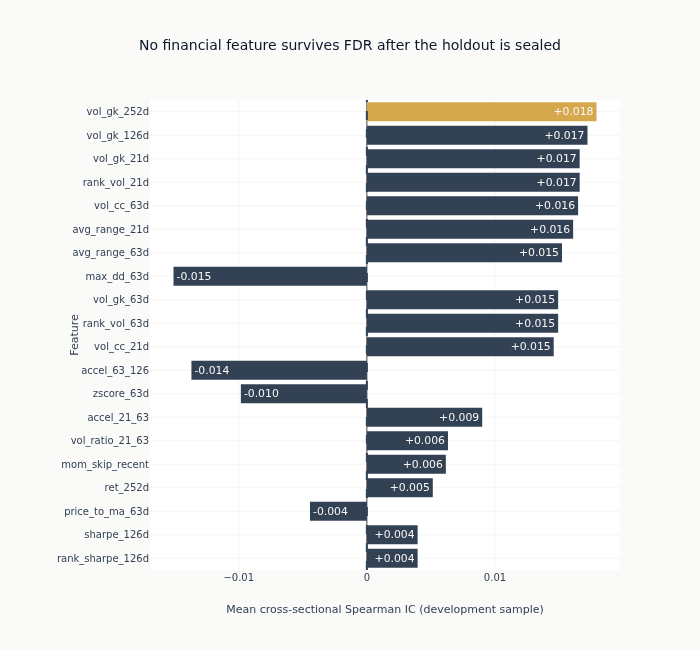

In [24]:
if ic_results and eval_summary is not None:
    top_20 = eval_summary.sort(pl.col("ic_mean").abs()).tail(20)
    _top_feature = top_20["feature"][-1]

    fig = go.Figure()
    colors = [
        COLORS["positive"]
        if sig
        else COLORS["amber"]
        if feature == _top_feature
        else COLORS["neutral"]
        for feature, sig in zip(top_20["feature"].to_list(), top_20["significant_fdr05"].to_list())
    ]
    fig.add_trace(
        go.Bar(
            x=top_20["ic_mean"].to_list(),
            y=top_20["feature"].to_list(),
            orientation="h",
            marker_color=colors,
            text=[f"{ic:+.3f}" for ic in top_20["ic_mean"].to_list()],
            textposition="inside",
            insidetextanchor="end",
            textfont=dict(color=COLORS["silver"]),
            showlegend=False,
        )
    )
    _ic_title = (
        f"{n_significant} features survive BH-FDR at 5%"
        if n_significant
        else "No financial feature survives FDR after the holdout is sealed"
    )
    fig.update_layout(
        title=_ic_title,
        xaxis_title="Mean cross-sectional Spearman IC (development sample)",
        yaxis_title="Feature",
        height=650,
        margin=dict(l=150),
    )
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.show()

### A Few Near-Duplicate Pairs Drive the Redundancy

A 51-by-51 heatmap is illegible at notebook width. The ranked pair chart
preserves the actionable information: which features are most redundant and
whether their relationship is positive or negative.

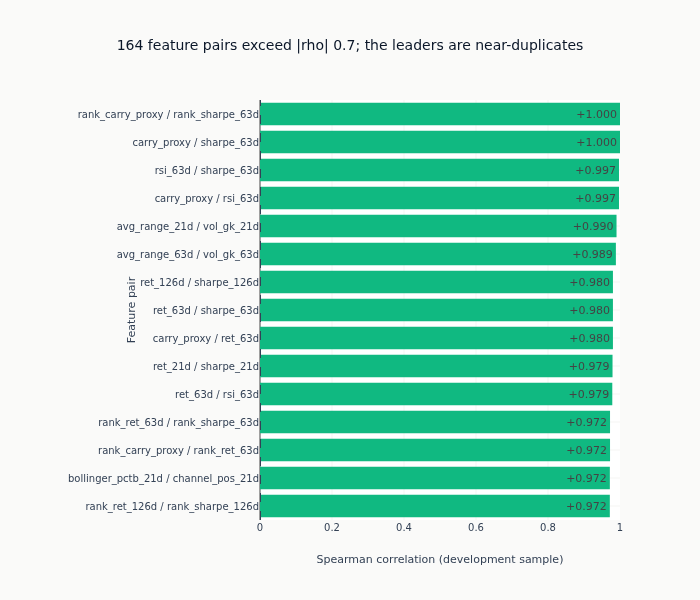

In [25]:
_sample_dates = eval_df["timestamp"].unique().sort().gather_every(5)
_corr_data = (
    eval_df.filter(pl.col("timestamp").is_in(_sample_dates))
    .select(FEATURE_COLS)
    .to_pandas()
    .corr(method="spearman")
)
high_corr_pairs = [
    (f1, f2, float(_corr_data.loc[f1, f2]))
    for f1, f2 in combinations(_corr_data.columns, 2)
    if abs(_corr_data.loc[f1, f2]) > 0.7
]
_top_corr = sorted(high_corr_pairs, key=lambda row: abs(row[2]))[-15:]
_corr_axis_range = [-1, 1] if any(corr < 0 for _, _, corr in _top_corr) else [0, 1]

fig = go.Figure(
    go.Bar(
        x=[corr for _, _, corr in _top_corr],
        y=[f"{f1} / {f2}" for f1, f2, _ in _top_corr],
        orientation="h",
        marker_color=[
            COLORS["positive"] if corr > 0 else COLORS["negative"] for _, _, corr in _top_corr
        ],
        text=[f"{corr:+.3f}" for _, _, corr in _top_corr],
        textposition="inside",
        showlegend=False,
    )
)
fig.update_layout(
    title=f"{len(high_corr_pairs)} feature pairs exceed |rho| 0.7; the leaders are near-duplicates",
    xaxis_title="Spearman correlation (development sample)",
    yaxis_title="Feature pair",
    xaxis_range=_corr_axis_range,
    height=600,
    margin=dict(l=260),
)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

### HAC and Naive Significance Are Similar, but Not Interchangeable

Absolute t-statistics make movement toward or away from zero unambiguous for
both positive and negative IC estimates. The diagonal is equality.

In [26]:
if ic_results and eval_summary is not None:
    _naive_abs = [abs(value) for value in eval_summary["naive_tstat"].to_list()]
    _hac_abs = [abs(value) for value in eval_summary["hac_tstat"].to_list()]
    _sig_colors = [
        COLORS["positive"] if sig else COLORS["neutral"]
        for sig in eval_summary["significant_fdr05"].to_list()
    ]
    _effective_lag = max(int(stats["effective_lags"]) for stats in ic_results.values())
    _max_t = max(max(_naive_abs), max(_hac_abs)) * 1.05

The scatter uses the same scale on both axes so departures from the equality
line reflect the HAC adjustment rather than unequal plotting ranges.

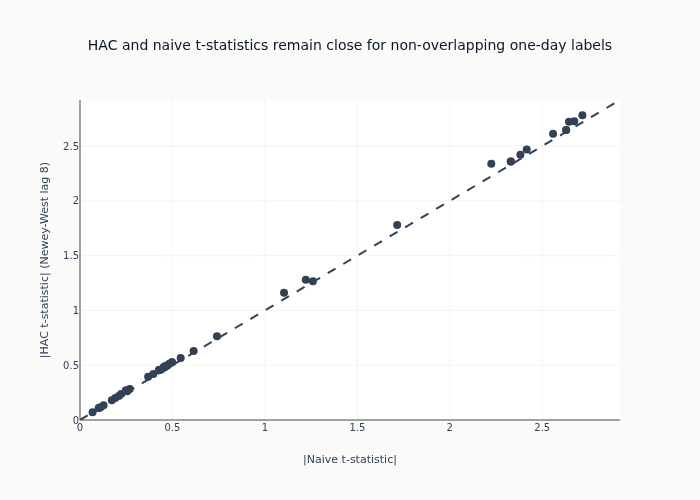

In [27]:
if ic_results and eval_summary is not None:
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=_naive_abs,
            y=_hac_abs,
            mode="markers",
            text=eval_summary["feature"].to_list(),
            marker=dict(color=_sig_colors, size=8),
            hovertemplate="%{text}<br>|naive t|=%{x:.2f}<br>|HAC t|=%{y:.2f}<extra></extra>",
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[0, _max_t],
            y=[0, _max_t],
            mode="lines",
            line=dict(dash="dash", color=COLORS["neutral"]),
            showlegend=False,
        )
    )
    fig.update_layout(
        title="HAC and naive t-statistics remain close for non-overlapping one-day labels",
        xaxis_title="|Naive t-statistic|",
        yaxis_title=f"|HAC t-statistic| (Newey-West lag {_effective_lag})",
        xaxis_range=[0, _max_t],
        yaxis_range=[0, _max_t],
        height=500,
        showlegend=False,
    )
    fig.show()

### Interpretation

The computed reflection below keeps the discovery count, leading IC, HAC
adjustment, and redundancy count tied to the executed development sample.

In [28]:
if ic_results and eval_summary is not None:
    _leader = eval_summary.row(0, named=True)
    _median_se_ratio = float(
        np.median([stats["hac_se"] / stats["naive_se"] for stats in ic_results.values()])
    )
    display(
        Markdown(
            f"""
**Finding.** The sealed development screen leaves **{n_significant} FDR-controlled discoveries**
among {len(ic_results)} tested features. The leading exploratory estimate is
`{_leader["feature"]}` with mean IC {_leader["ic_mean"]:+.4f} and HAC t-statistic
{_leader["hac_tstat"]:+.2f}. The median HAC-to-naive standard-error ratio is
{_median_se_ratio:.2f} at Newey-West lag {_effective_lag}.

The 20-pair cross-section makes daily ranks noisy, and {len(high_corr_pairs)} pairs exceed
an absolute correlation of 0.7. Downstream models should therefore treat individual IC rankings
as exploratory and rely on regularization rather than interpreting near-duplicate inputs as
independent evidence.
"""
        )
    )


**Finding.** The sealed development screen leaves **0 FDR-controlled discoveries**
among 48 tested features. The leading exploratory estimate is
`vol_gk_252d` with mean IC +0.0179 and HAC t-statistic
+2.78. The median HAC-to-naive standard-error ratio is
0.95 at Newey-West lag 8.

The 20-pair cross-section makes daily ranks noisy, and 164 pairs exceed
an absolute correlation of 0.7. Downstream models should therefore treat individual IC rankings
as exploratory and rely on regularization rather than interpreting near-duplicate inputs as
independent evidence.


## 13. Results Collection

The helper records the source revision in the in-memory result summary. This
notebook does not write the summary to the frozen registry.

In [29]:
def _git_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], text=True, timeout=5
        ).strip()
    except Exception:
        return "unknown"

### Feature-Construction Metadata

The summary captures the artifact shape and the definitions a downstream
report would need without duplicating the feature matrix itself.

In [30]:
results = {
    "case_study_id": "fx_pairs",
    "chapter": 8,
    "stage": "features",
    "timestamp": datetime.now(UTC).isoformat(),
    "git_commit": _git_hash(),
    "notebook": "case_studies/fx_pairs/03_financial_features.py",
    "summary": {
        "n_features": n_features,
        "n_rows": n_rows,
        "n_pairs": int(output_df["symbol"].n_unique()),
        "n_dates": int(output_df["timestamp"].n_unique()),
        "frequency": "daily_ny_5pm",
        "date_range": [str(output_df["timestamp"].min()), str(output_df["timestamp"].max())],
    },
}
results["techniques"] = {
    "families": {k: len(v) for k, v in families.items() if v},
    "usd_strength_proxy": "signed_average_of_usd_pair_returns",
    "carry_proxy": "legacy risk_adjusted_momentum field; true carry unavailable",
}
results["diagnostics"] = {
    "max_null_pct": float(max_null),
    "warmup_rows_dropped": n_before - n_rows,
}
results["key_findings"] = [
    f"Computed {n_features} features on the daily session calendar",
    "A signed USD-return average separates broad dollar moves from pair variation",
    "Mean reversion features are the main hypothesis-driven family",
    "The legacy carry proxy is momentum-based because interest-rate data are unavailable",
]

### Development-Sample Evaluation Metadata

The evaluation block records the sealed screen and its HAC/FDR settings. It
remains an in-memory teaching artifact and does not mutate the registry.

In [31]:
if ic_results:
    assert eval_summary is not None
    _family_ic = {}
    for feat, stats in ic_results.items():
        family = assign_feature_family(feat)
        _family_ic.setdefault(family, []).append(stats["mean_ic"])
    _family_avg_ic = {f: float(np.mean(ics)) for f, ics in _family_ic.items()}

    results["evaluation"] = {
        "primary_label": "fwd_ret_1d",
        "n_features_tested": len(ic_results),
        "n_significant_naive05": n_naive_sig,
        "n_significant_hac05": n_hac_sig,
        "n_significant_fdr05": n_significant,
        "hac_lag": _effective_lag,
        "top_features": [
            {
                "name": row["feature"],
                "ic_mean": round(row["ic_mean"], 4),
                "hac_tstat": round(row["hac_tstat"], 2),
                "hac_pval": round(row["p_value"], 4),
            }
            for row in eval_summary.head(10).to_dicts()
        ],
        "max_pairwise_corr": (
            round(max(abs(c) for _, _, c in high_corr_pairs), 3) if high_corr_pairs else 0.0
        ),
        "corr_pairs_above_07": len(high_corr_pairs),
        "feature_family_avg_ic": {
            k: round(v, 4) for k, v in sorted(_family_avg_ic.items(), key=lambda x: -abs(x[1]))
        },
    }

## Key Takeaways

1. **Daily frequency**: All features computed on daily prices (NY 5PM close),
   matching the label pipeline's session convention.
2. **Mean-reversion focus**: Z-scores and channel position features are the
   main hypothesis-driven family, while the sealed IC screen treats every
   individual ranking as exploratory.
3. **USD strength proxy**: A signed average of the seven USD pairs separates
   broad dollar moves from pair-specific variation without claiming a PCA model.
4. **Redundancy matters**: Several feature pairs are near-duplicates, so
   downstream estimation should use regularization rather than raw IC ranking.
5. **Carry limitation**: The retained legacy field is risk-adjusted momentum,
   not an interest-rate differential, and should be interpreted accordingly.

**Next**: `04_model_based_features.py` adds causal, walk-forward temporal
features before the combined evaluation in `05_evaluation.py`.